# Gráficas KNN CPU/GPU

In [1]:

import matplotlib.pyplot as plt


In [2]:

# Datos CPU

cpu_2 = {
    1000: 8.90069,
    10000: 88.9805,
    50000: 447.931,
    100000: 612.425,
    200000: 1245.36
}

cpu_4 = {
    1000: 1.6996,
    10000: 16.9745,
    50000: 84.977,
    100000: 169.901,
    200000: 340.256,
    500000: 1014.19
}

cpu_8 = {
    1000: 0.886852,
    10000: 8.92887,
    50000: 44.3732,
    100000: 97.9069,
    200000: 184.244,
    500000: 483.566
}

cpu_16 = {
    1000: 0.70409,
    10000: 6.3868,
    50000: 31.4465,
    100000: 63.0683,
    200000: 101.957,
    500000: 302.569,
    1000000: 742.326
}

gpu = {
    1000: 0.788673,
    10000: 1.23904,
    50000: 6.13132,
    100000: 11.6148,
    200000: 23.0932,
    500000: 56.4542,
    1000000: 112.818
}


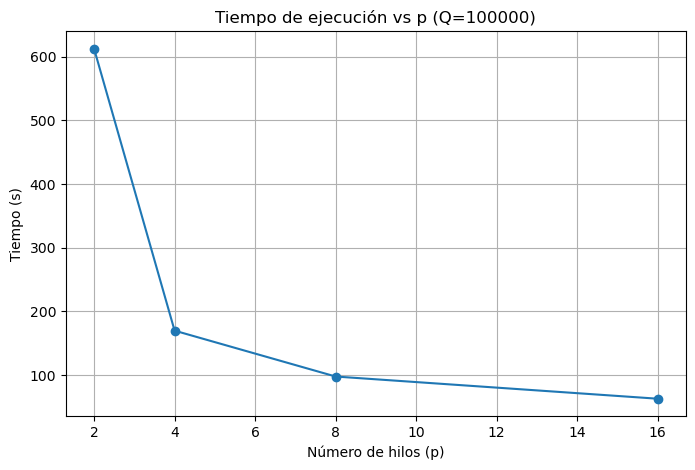

In [3]:

# 1. Tiempo de ejecución vs p (Q=100000)

p = [2,4,8,16]
tiempos = [612.425,169.901,97.9069,63.0683]

plt.figure(figsize=(8,5))
plt.plot(p, tiempos, marker='o')
plt.xlabel('Número de hilos (p)')
plt.ylabel('Tiempo (s)')
plt.title('Tiempo de ejecución vs p (Q=100000)')
plt.grid(True)
plt.savefig('cpu_tiempo_vs_p.png')
plt.show()


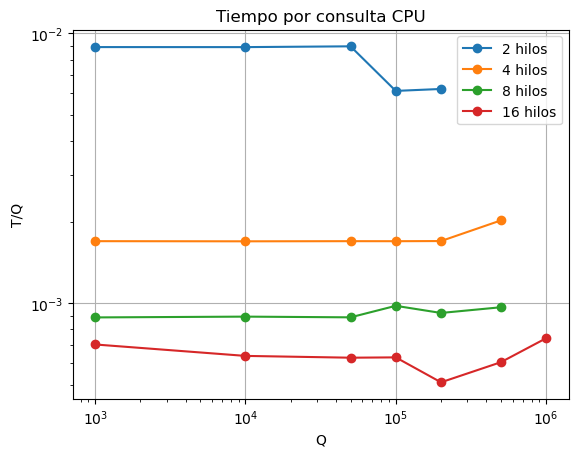

In [4]:

# 2. Tiempo por consulta CPU

for data,label in [(cpu_2,'2 hilos'),(cpu_4,'4 hilos'),(cpu_8,'8 hilos'),(cpu_16,'16 hilos')]:
    q=list(data.keys())
    tq=[v/k for k,v in data.items()]
    plt.plot(q,tq,marker='o',label=label)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Q')
plt.ylabel('T/Q')
plt.title('Tiempo por consulta CPU')
plt.legend()
plt.grid(True)
plt.savefig('cpu_tq_vs_q.png')
plt.show()


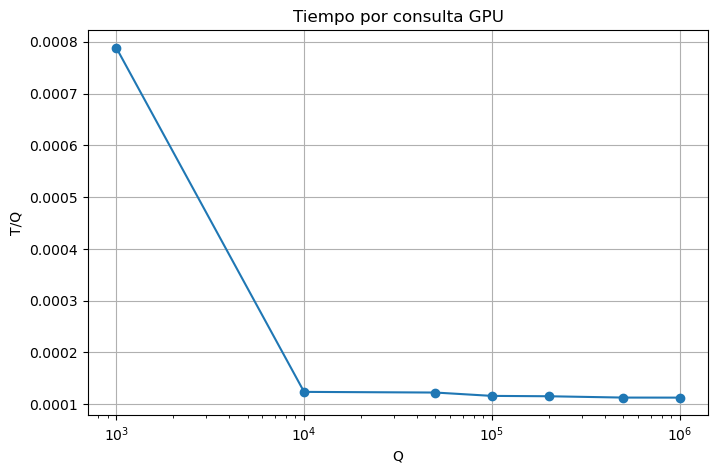

In [5]:

# 3. Tiempo por consulta GPU

Q=list(gpu.keys())
TQ=[v/k for k,v in gpu.items()]

plt.figure(figsize=(8,5))
plt.plot(Q,TQ,marker='o')
plt.xscale('log')
plt.xlabel('Q')
plt.ylabel('T/Q')
plt.title('Tiempo por consulta GPU')
plt.grid(True)
plt.savefig('gpu_tq_vs_q.png')
plt.show()


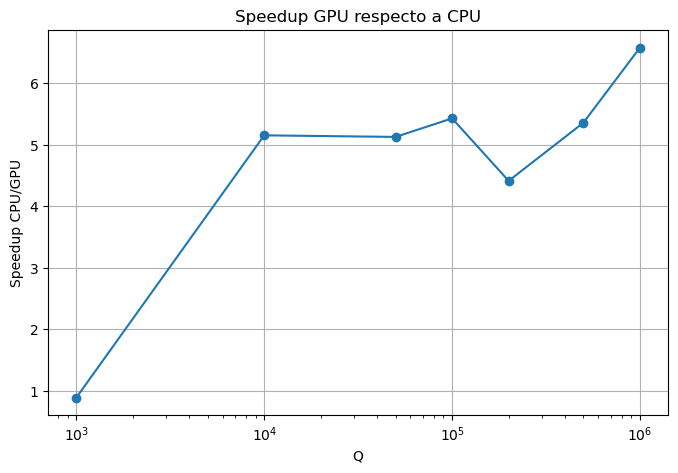

In [6]:

# 4. Speedup GPU respecto a CPU

Q=list(gpu.keys())
speedup=[cpu_16[q]/gpu[q] for q in Q]

plt.figure(figsize=(8,5))
plt.plot(Q,speedup,marker='o')
plt.xscale('log')
plt.xlabel('Q')
plt.ylabel('Speedup CPU/GPU')
plt.title('Speedup GPU respecto a CPU')
plt.grid(True)
plt.savefig('speedup_gpu_cpu.png')
plt.show()


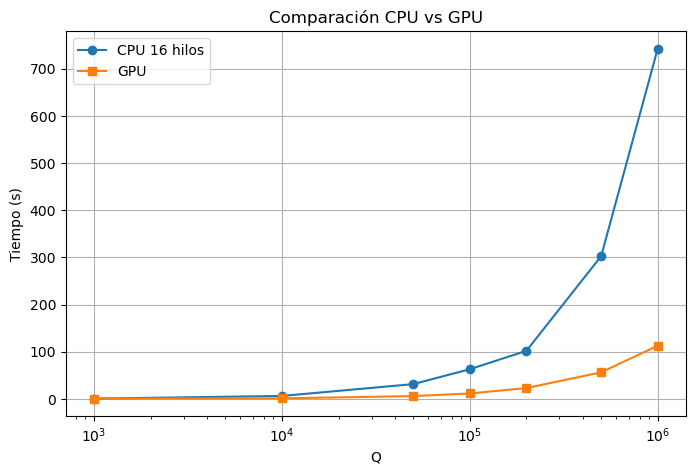

In [7]:

# 5. Comparación CPU vs GPU

Q=list(gpu.keys())
cpu=[cpu_16[q] for q in Q]
gpu_t=[gpu[q] for q in Q]

plt.figure(figsize=(8,5))
plt.plot(Q,cpu,marker='o',label='CPU 16 hilos')
plt.plot(Q,gpu_t,marker='s',label='GPU')
plt.xscale('log')
plt.xlabel('Q')
plt.ylabel('Tiempo (s)')
plt.title('Comparación CPU vs GPU')
plt.legend()
plt.grid(True)
plt.savefig('comparacion_cpu_gpu.png')
plt.show()
